In [1]:
from statsmodels.stats.anova import AnovaRM

import sys
sys.path.append('../mdi/')
import globals as gl

import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import os
import pandas as pd

plt.style.use('default')

base directory: /cifs/diedrichsen/data/ModifiedDigitInterference/


In [2]:
data = pd.read_csv('/cifs/diedrichsen/data/ModifiedDigitInterference/behavioural/MDI0_merged1.csv')
N = data.SID.nunique()
data = data[(data.correct==1) & (data.BN>1)]
data[['ipi1', 'ipi2', 'ipi3', 'ipi4']] = data[['ipi1', 'ipi2', 'ipi3', 'ipi4']].astype(float)
data.PosInQuartet = pd.Categorical(data.PosInQuartet, categories=[1, 2, 3, 4], ordered=True)
data.Quartet = pd.Categorical(data.Quartet, categories=['AAAA', 'AAMA', 'AARA'], ordered=True)

data.head(6)

,BN,TN,startTR,startTRReal,startTimeReal,planTime,execTime,feedbackTime,iti,expectedDigit1,...,SN,SID,PosInQuartet,Quartet,planError,correct,ipi1,ipi2,ipi3,ipi4
74,2,3,0,15,14471,1000,5000,1000,500,5,...,0,100,3,AAMA,False,True,945.0,700.0,325.0,320.0
75,2,4,0,20,19606,1000,5000,1000,500,5,...,0,100,4,AAMA,False,True,550.0,410.0,365.0,265.0
76,2,5,0,25,24666,1000,5000,1000,500,2,...,0,100,1,AARA,False,True,370.0,425.0,395.0,385.0
79,2,8,0,43,42281,1000,5000,1000,500,2,...,0,100,4,AARA,False,True,825.0,560.0,505.0,555.0
80,2,9,0,48,47901,1000,5000,1000,500,4,...,0,100,1,AARA,False,True,685.0,940.0,570.0,650.0
82,2,11,0,60,59621,1000,5000,1000,500,4,...,0,100,3,AARA,False,True,540.0,640.0,255.0,80.0


/home/alily/Documents/GitHub/modified-digit-inteference/.venv/lib/python3.12/site-packages/pingouin/distribution.py:514: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,ng2,eps
0,Quartet,121788.455393,2,32,60894.227697,4.761945,1.547502e-02,1.926825e-02,0.002964,0.895376
1,PosInQuartet,522586.094641,3,48,174195.364880,23.273090,1.914638e-09,8.613502e-08,0.012596,0.777312
2,Quartet * PosInQuartet,49186.555845,6,96,8197.759308,1.255368,2.853986e-01,3.003504e-01,0.001199,0.489227


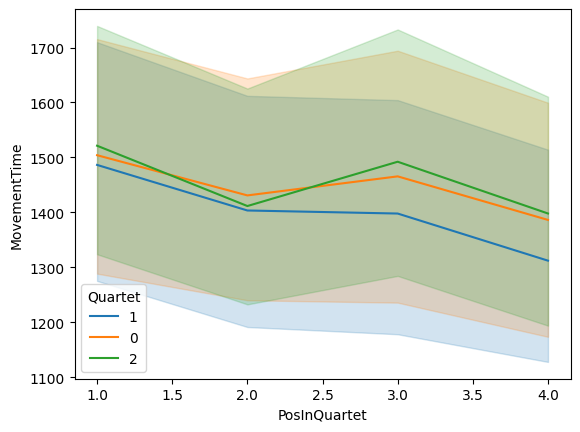

In [3]:
import pingouin as pg
import seaborn as sns

#condition_data = data[(data.Quartet!="AAAA")]
condition_data = data.groupby(["SID","Quartet","PosInQuartet"]).mean(numeric_only=True).reset_index()
condition_data.Quartet = condition_data.Quartet.map({'AAMA': 0, 'AAAA': 1, 'AARA': 2})

sns.lineplot(data=condition_data, y='MovementTime', x='PosInQuartet', hue='Quartet')

anova = pg.rm_anova(data=condition_data, dv='MovementTime', within=["Quartet","PosInQuartet"], subject='SID')

display(anova)


In [4]:
melted_ipi = condition_data.melt(id_vars=["Quartet", 'SID', 'PosInQuartet', 'TN', 'BN'],value_vars=["ipi1","ipi2","ipi3","ipi4"], value_name="IPI", var_name="IPI_id")
melted_ipi['IPI'] = (melted_ipi['IPI'] - melted_ipi.groupby('SID')['IPI'].transform('mean'))
melted_ipiG = melted_ipi.groupby(['SID', 'Quartet', 'PosInQuartet', 'IPI_id'], observed=True).mean(numeric_only=True).reset_index()
melted_ipiG['IPI'] += melted_ipiG['IPI'].mean()



In [5]:
melted_ipi.head(6)

,Quartet,SID,PosInQuartet,TN,BN,IPI_id,IPI
0,1,100,1,42.714286,6.321429,ipi1,49.879604
1,1,100,2,43.333333,5.444444,ipi1,-0.490767
2,1,100,3,44.925926,5.740741,ipi1,73.027752
3,1,100,4,43.652174,5.565217,ipi1,21.836125
4,0,100,1,34.846154,5.846154,ipi1,101.225757
5,0,100,2,31.037037,5.962963,ipi1,-22.527804


In [10]:
ipi_anova = pg.rm_anova(data=melted_ipi, dv='IPI', within=["IPI_id","PosInQuartet"], subject='SID')
display(ipi_anova)

/home/alily/Documents/GitHub/modified-digit-inteference/.venv/lib/python3.12/site-packages/pingouin/distribution.py:514: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,ng2,eps
0,IPI_id,107294.114474,3,48,35764.704825,12.421202,3.906332e-06,3.005217e-05,0.386659,0.790848
1,PosInQuartet,30906.520020,3,48,10302.173340,43.271856,1.082991e-13,3.909764e-10,0.153685,0.693157
2,IPI_id * PosInQuartet,3064.415581,9,144,340.490620,2.384670,1.515315e-02,1.111104e-01,0.017687,0.212415
